--- Loading and preparing data ---
data.csv not found. Creating dummy data.csv for demonstration.
Dataset Shape: (100, 18)

Missing values per column before cleaning:
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
city             0
statezip         0
date             0
street           0
country          0
dtype: int64

--- Training and evaluating baseline architectures ---
Linear Regression    -> RMSE: $   284070.42 | MAE: $   220055.95 | R²: -0.3697
Random Forest        -> RMSE: $   283825.60 | MAE: $   207261.95 | R²: -0.3674
Gradient Boosting    -> RMSE: $   281757.08 | MAE: $   226598.21 | R²: -0.3475

--- Best Model Selection: Gradient Boosting ---
Saved residual evaluation visual as 'residual_analysis.png'.


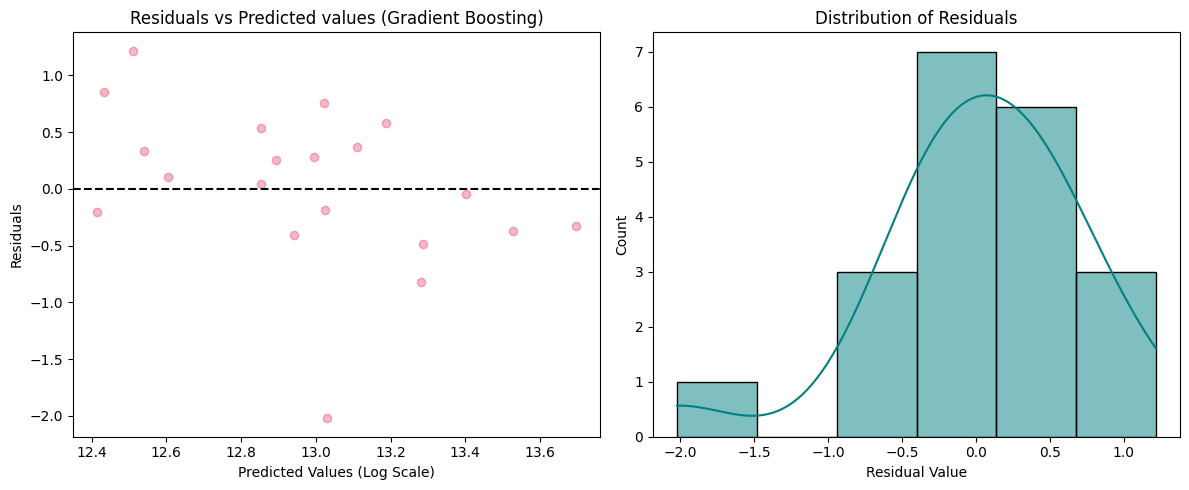


Successfully stored end-to-end model asset: 'best_house_predictor.pkl'


In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model implementations
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ==========================================
# 1. DATA LOADING & EXPLORATORY ANALYSIS (EDA)
# ==========================================
print("--- Loading and preparing data ---")

# Check if data.csv exists, if not, create dummy data
if not os.path.exists("data.csv"):
    print("data.csv not found. Creating dummy data.csv for demonstration.")
    # Create dummy data that mimics the expected structure
    dummy_data = {
        'price': np.random.rand(100) * 1000000 + 50000, # Realistic prices
        'bedrooms': np.random.randint(1, 6, 100),
        'bathrooms': np.random.randint(1, 4, 100) + np.random.choice([0, 0.5], 100),
        'sqft_living': np.random.randint(800, 5000, 100),
        'sqft_lot': np.random.randint(2000, 20000, 100),
        'floors': np.random.choice([1, 1.5, 2, 2.5], 100),
        'waterfront': np.random.randint(0, 2, 100),
        'view': np.random.randint(0, 5, 100),
        'condition': np.random.randint(1, 6, 100),
        'sqft_above': np.random.randint(700, 4000, 100),
        'sqft_basement': np.random.randint(0, 2000, 100),
        'yr_built': np.random.randint(1900, 2020, 100),
        'yr_renovated': np.random.choice([0] + list(range(1990, 2020)), 100),
        'city': np.random.choice(['Seattle', 'Bellevue', 'Redmond'], 100),
        'statezip': np.random.choice(['WA 98101', 'WA 98004', 'WA 98052'], 100),
        'date': pd.to_datetime('2014-05-01') + pd.to_timedelta(np.random.randint(0, 365, 100), unit='D'),
        'street': [f'Street {i}' for i in range(100)],
        'country': ['USA'] * 100
    }
    dummy_df = pd.DataFrame(dummy_data)
    dummy_df.to_csv("data.csv", index=False)

# Load data (Assuming data.csv is extracted or in the same path)
df = pd.read_csv("data.csv")

# Quick Look at the shape & missing entries
print(f"Dataset Shape: {df.shape}")
print("\nMissing values per column before cleaning:")
print(df.isnull().sum())

# Drop high cardinality columns that are unique to each record to avoid overfitting
# 'country' has no variance if it's all 'USA'. 'date' and 'street' are excluded here.
columns_to_drop = ['date', 'street', 'country']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Handle Target Variable: House Prices
# Note: House prices often feature extreme values or 0 entries that need safety filtering
df = df[df['price'] > 0].reset_index(drop=True)

# Separate features (X) and log-transformed target (y)
# Log-transformation handles severe right-skewness commonly found in asset pricing
X = df.drop(columns=['price'])
y = np.log1p(df['price'])

# ==========================================
# 2. FEATURE ENGINEERING & PIPELINE DESIGN
# ==========================================
# Categorize our columns for custom pre-processing treatment
numeric_features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
                    'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
                    'yr_built', 'yr_renovated']
categorical_features = ['city', 'statezip']

# Numeric feature processing: Impute missing values with median -> scale data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical feature processing: Impute missing values with mode -> One Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine all engineering into a comprehensive preprocessor unit
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Train-Test Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 3. MODEL SELECTION & BENCHMARK COMPARISONS
# ==========================================
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
best_model_name = None
best_rmse = float('inf')
best_pipeline = None

print("\n--- Training and evaluating baseline architectures ---")
for name, model in models.items():
    # Construct an atomic end-to-end operational pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])

    # Train the pipeline
    pipeline.fit(X_train, y_train)

    # Generate predictions on log scale
    log_preds = pipeline.predict(X_test)

    # Convert predictions back to original USD scale for business reporting
    actuals = np.expm1(y_test)
    predictions = np.expm1(log_preds)

    # Performance Metric Evaluation
    mae = mean_absolute_error(actuals, predictions)
    mse = mean_squared_error(actuals, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(actuals, predictions)

    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Pipeline': pipeline, 'Log_Preds': log_preds}
    print(f"{name:20} -> RMSE: ${rmse:12.2f} | MAE: ${mae:12.2f} | R²: {r2:.4f}")

    # Track model showing the lowest generalization error
    if rmse < best_rmse:
        best_rmse = rmse
        best_model_name = name
        best_pipeline = pipeline

# ==========================================
# 4. RESIDUAL ANALYSIS (For Best Performer)
# ==========================================
print(f"\n--- Best Model Selection: {best_model_name} ---")
best_preds_log = results[best_model_name]['Log_Preds']
residuals = y_test - best_preds_log

plt.figure(figsize=(12, 5))

# Plot 1: Residuals Scatter Plot vs Predicted Log values
plt.subplot(1, 2, 1)
plt.scatter(best_preds_log, residuals, alpha=0.3, color='crimson')
plt.axhline(y=0, color='black', linestyle='--')
plt.title(f'Residuals vs Predicted values ({best_model_name})')
plt.xlabel('Predicted Values (Log Scale)')
plt.ylabel('Residuals')

# Plot 2: Histogram of Residuals to evaluate error normality
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='teal')
plt.title('Distribution of Residuals')
plt.xlabel('Residual Value')

plt.tight_layout()
plt.savefig('residual_analysis.png')
print("Saved residual evaluation visual as 'residual_analysis.png'.")
plt.show()

# ==========================================
# 5. PERSISTING DEPLOYMENT ASSETS
# ==========================================
model_filename = 'best_house_predictor.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_pipeline, file)

print(f"\nSuccessfully stored end-to-end model asset: '{model_filename}'")

In [3]:
import pickle
import numpy as np
import pandas as pd

# 1. Load the binary architecture (includes scaling/encoding definitions natively)
with open('best_house_predictor.pkl', 'rb') as file:
    loaded_pipeline = pickle.load(file)

# 2. Craft a new out-of-sample data point matching standard row features
raw_query_data = {
    'bedrooms': [3.0],
    'bathrooms': [2.5],
    'sqft_living': [2200],
    'sqft_lot': [7500],
    'floors': [1.5],
    'waterfront': [0],
    'view': [0],
    'condition': [4],
    'sqft_above': [1600],
    'sqft_basement': [600],
    'yr_built': [1985],
    'yr_renovated': [2010],
    'city': ['Seattle'],
    'statezip': ['WA 98115']
}

# Convert dictionary input to Pandas DataFrame format
query_df = pd.DataFrame(raw_query_data)

# 3. Generate prediction output
# Log scale prediction vector output
log_prediction = loaded_pipeline.predict(query_df)

# Inverse transform the log scale back into real-world dollar valuations
final_usd_valuation = np.expm1(log_prediction)[0]

print(f"Predicted Property Market Value: ${final_usd_valuation:,.2f}")

Predicted Property Market Value: $480,373.01
